# The MOS explorers, old and new

Two interactive widgets side by side: `vizs.MOS_interactive` as it was before this work,
now frozen in `biotuner.mos.legacy` because the function in the repo delegates to the
replacement — and `biotuner.mos.mos_explorer`.

**Run this top to bottom in Jupyter.** ipywidgets needs a live kernel; the widgets will
not appear in a static render of this notebook.

Requirements: `pip install ipywidgets plotly`

In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import math
import matplotlib.pyplot as plt
import numpy as np

import biotuner.mos as M

plt.rcParams["figure.dpi"] = 96
print("ready")

C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\epic-morse-ded0d5\biotuner\biotuner_object.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


ready


## 1. The original — `vizs.MOS_interactive`, now `mos.legacy.MOS_interactive`

Five generator sliders (1.0–2.0) with toggles, a max-steps slider and a Play button. For
each active generator it plots the stacked degrees as a spiral, radius = step index. It
also tries to draw a dashed radial wherever two generators produce a coinciding tone.

It lives in `biotuner.mos.legacy` now — frozen, same maths, same defaults — because
`vizs.MOS_interactive` delegates to the replacement and would otherwise leave the original
reachable only through `git show`.

Two things to notice while using it. There are no rings, arcs, spokes or landmarks, so
none of the paper's readings are available; and the radius is the index of the stacked
generator, not the cardinality of anything.

A third thing you will *not* notice: the dashed common-tone radials never appear. The test
is exact float equality between independently computed angles, so it fires for no generator
pair at all — measured, not assumed. That is why `theory.common_tones` uses a cents
tolerance.

In [2]:
M.legacy.MOS_interactive()

Output()

### The two figures, side by side

No widgets, just the output each one draws for the same three generators.

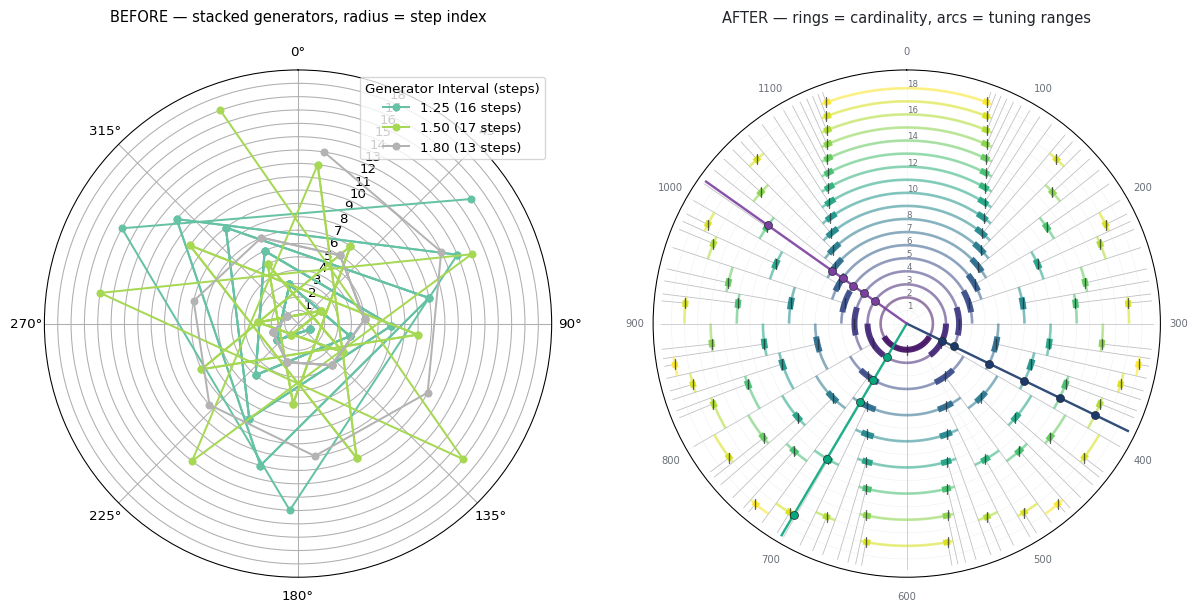

In [3]:
GENS = [1.25, 1.5, 1.8]

fig = plt.figure(figsize=(15, 7))
a1 = fig.add_subplot(1, 2, 1, projection="polar")
M.legacy.plot_MOS_spiral(GENS, max_steps=18, ax=a1)
a1.set_title("BEFORE — stacked generators, radius = step index", fontsize=11, pad=18)

a2 = fig.add_subplot(1, 2, 2, projection="polar")
M.plot_labyrinth(18, ax=a2, highlight=[M.generator_fraction(g) for g in GENS])
a2.get_legend().remove()
a2.set_title("AFTER — rings = cardinality, arcs = tuning ranges", fontsize=11, pad=18)
plt.show()

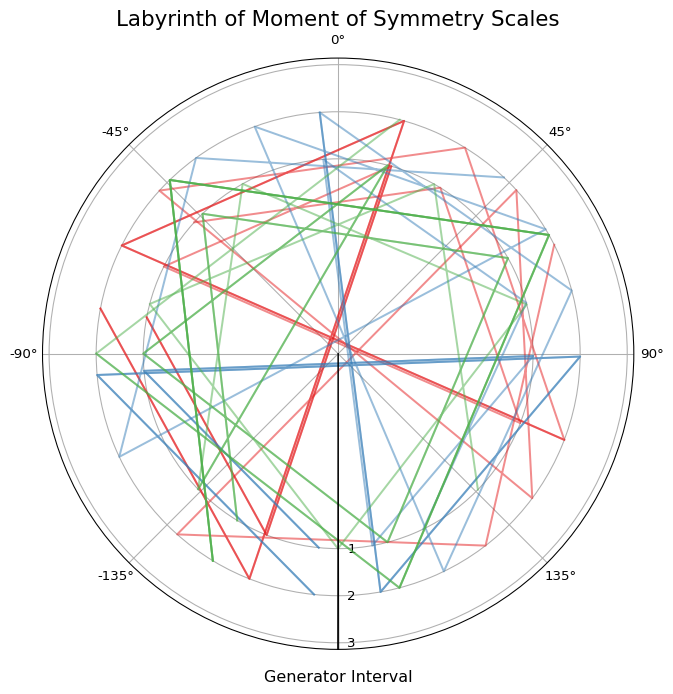

(<Figure size 768x768 with 1 Axes>,
 <PolarAxes: title={'center': 'Labyrinth of Moment of Symmetry Scales'}, xlabel='Generator Interval'>)

In [4]:
# And the old static one, for completeness. Every scale lands on radius 1 or 2.
M.legacy.plot_labyrinth([4 / 3, 3 / 2, 9 / 5], max_steps=16)

## 2. The replacement — `mos_explorer`

Same two good ideas — several generators at once, and their common tones — on top of the
actual labyrinth. Drag a generator and the family recomputes, the wheel redraws, the
summary updates and the fit against your signal is re-scored.

Controls:

| | |
|---|---|
| `gen 1…5` | toggle a generator on or off; the first *active* one is focused |
| slider beside each | that generator, in cents |
| `period ratio` | the pseudo-octave — the paper treats it as a free parameter |
| `max rings` | outermost cardinality |
| `cardinality` | which ring of the focused generator's family to inspect |
| `overlays` | signal peaks, named temperaments, coherence bands, common tones |
| `common tol ¢` | how close two generators' tones must be to count as shared |
| `▶ play scale` | sonify the focused scale (needs `pygame`) |
| `copy .scl` | print a Scala file for it |

In [5]:
# A synthetic stack of fifths, as used throughout the report.
PEAKS = [1.0, 1.125, 1.3333, 1.5, 1.6875]

M.mos_explorer(ratios=PEAKS)

Switch on `gen 2` and drag it. With two generators active the dotted radial lines appear
at their shared tones, and the text panel lists them. Two generators of the same equal
division share all of it; a generator and its complement share only the root, because
they build the same scale *mirrored* rather than the same set of pitches.

In [6]:
# Start with two generators already on: the fifth and the 31-EDO meantone fifth.
M.mos_explorer(ratios=PEAKS, generators=[3 / 2, 2 ** (18 / 31)], n_generators=3)

### Bound to a real signal

Give it a `compute_biotuner` instead of raw ratios and the peaks come from the signal,
weighted by amplitude, with the first generator seeded at the best-fitting one.

In [7]:
from biotuner.biotuner_object import compute_biotuner

rng = np.random.default_rng(7)
sf = 1000.0
t = np.arange(0, 30, 1 / sf)
base = 5.0
partials = [base, base * 1.5, base * 2.25, base * 3.375, base * 2.0]
amps = [1.0, 0.9, 0.75, 0.5, 0.65]
signal = sum(a * np.sin(2 * np.pi * f * t) for a, f in zip(amps, partials))
signal = signal + 0.25 * rng.standard_normal(t.size)

bt = compute_biotuner(sf, peaks_function="FOOOF", precision=0.1)
bt.peaks_extraction(signal, min_freq=2, max_freq=40, n_peaks=5)
print("peaks:", np.round(bt.peaks, 3))

M.mos_explorer(bt)

peaks: [ 5.    7.5   9.99 11.25 16.88]


## 3. `fit_explorer` — inspect the runners-up

The ranked fits, one per dropdown entry, each with its residuals and its position in the
labyrinth. A close second is common, and the ranking is only as good as its parsimony
penalty, so it is worth looking rather than trusting.

In [8]:
M.fit_explorer(bt.peaks_ratios, max_cardinality=16)

## 4. `scratch_explorer` — Fourier Scratching

A slider per Fourier coefficient. Moving one reshapes the whole play state at once, which
is the point of the technique. It opens on the first partial, which strikes every tone
exactly once in ascending order.

In [9]:
d12 = M.MOSScale.from_signature(5, 2, tuning=12)
M.scratch_explorer(M.christoffel_mode(d12))

## 5. `labyrinth_plotly` — no kernel needed

Hover-rich and zoomable, and with `generator_slider=True` it gets a precomputed slider,
so the exported file stays interactive with nothing running behind it.

In [10]:
fig = M.labyrinth_plotly(16, peaks=bt.peaks_ratios, temperaments=True,
                         generator_slider=True, slider_steps=97)
fig

In [11]:
fig.write_html("labyrinth.html")
print("wrote labyrinth.html — opens in any browser, no Python required")

wrote labyrinth.html — opens in any browser, no Python required


## 6. The other labyrinths

Not interactive, but worth a look from here since everything is loaded.

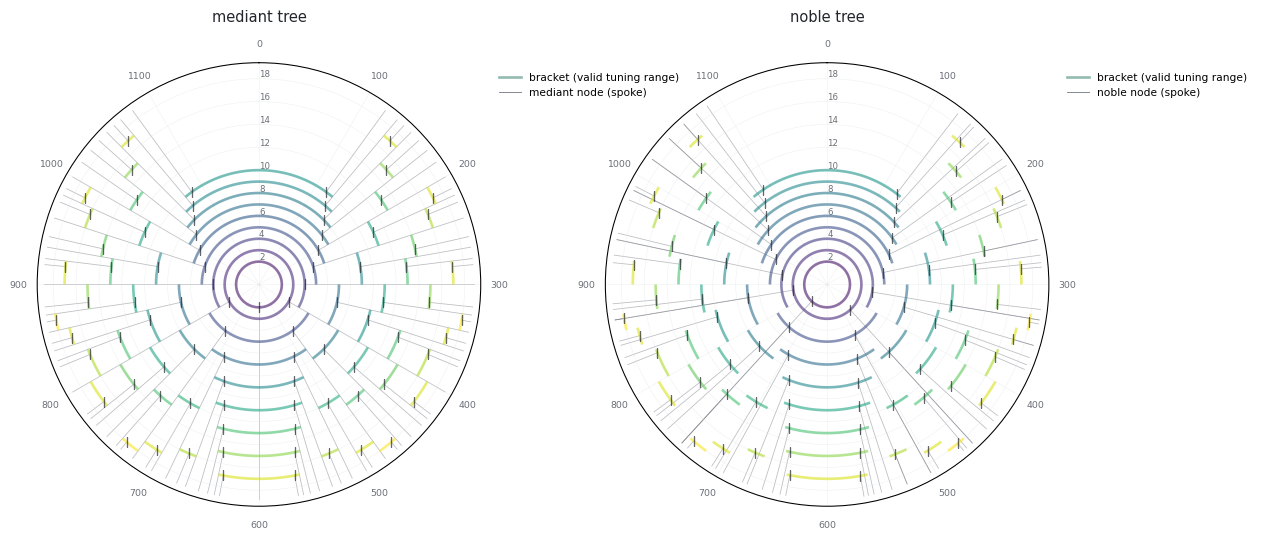

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "polar"})
M.plot_labyrinth_variant(rule=M.MEDIANT, max_cardinality=18, ax=axes[0])
M.plot_labyrinth_variant(rule=M.NOBLE, max_cardinality=18, ax=axes[1])
axes[0].set_title("mediant tree", fontsize=11, pad=14)
axes[1].set_title("noble tree", fontsize=11, pad=14)
plt.show()

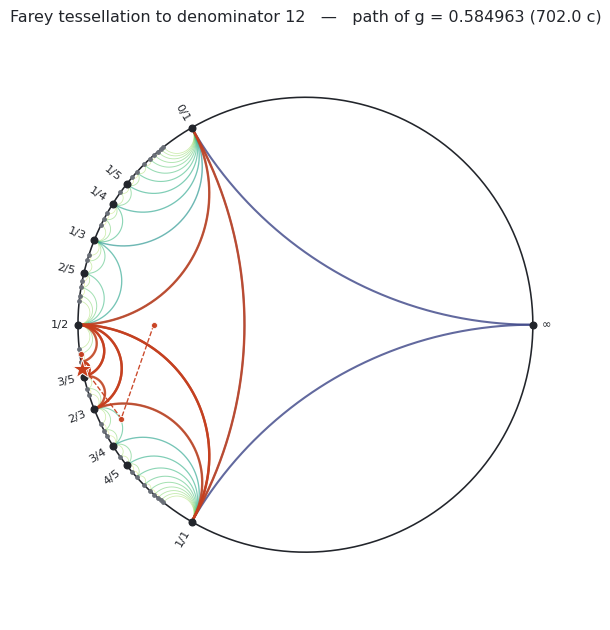

In [13]:
M.plot_farey_tessellation(12, highlight_generator=math.log2(3 / 2))
plt.show()

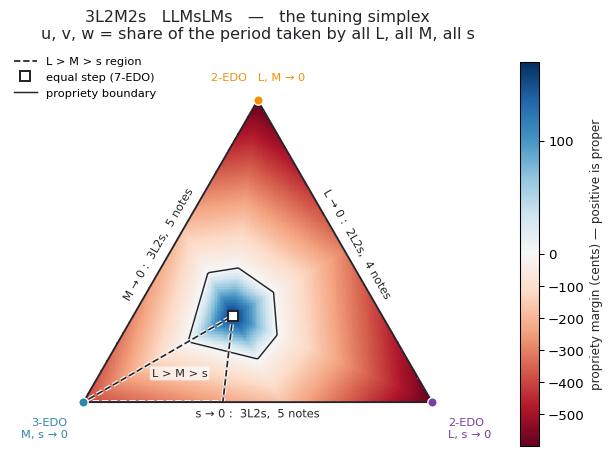

In [14]:
M.plot_ternary_simplex("LLMsLMs", field="propriety")
plt.show()

## 7. `web_explorer` — the scale as a figure

The design counterpart. Drag the generator and the star polygon reforms; step through the
modes and the silhouette rotates; switch style and the same scale is redrawn five ways.

Each style encodes something rather than decorating:

| style | what the shape means |
|---|---|
| `chain` | degrees joined in generator order — a **star polygon** `{N/d}`, the circle of fifths made visible |
| `ring` | degrees joined in pitch order — edge lengths *are* the step sizes |
| `web` | every interval, weighted by harmonicity — the bright heavy lines are the consonances |
| `nested` | the whole family, so the embedding shows as concentric shapes |
| `spiral` | the original stacked-generator figure, rebuilt |

The star's density is the modular *inverse* of Carey's WF number, not the number itself.
For the diatonic, WF(7, 2) means one scale step is two fifths, so one fifth is four scale
steps and the figure is the heptagram `{7/3}`.

In [15]:
M.web_explorer(3 / 2)

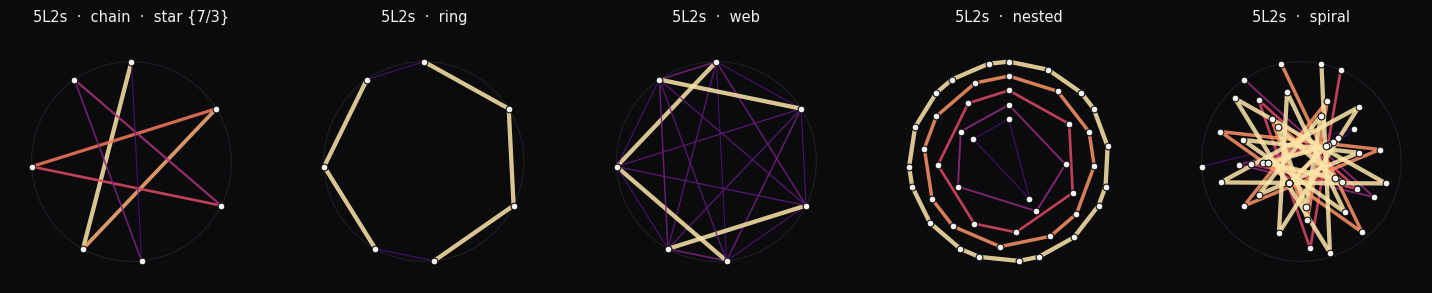

In [16]:
# All five styles for one scale.
d31 = M.MOSScale.from_signature(5, 2, tuning=31)
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))
for ax, st in zip(axes, M.STYLES):
    M.plot_scale_web(d31, st, ax=ax, palette="noir", max_cardinality=29)
plt.show()

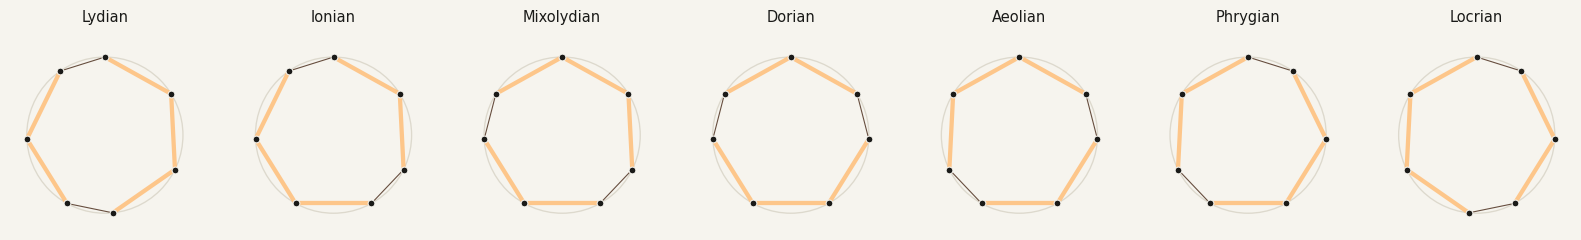

In [17]:
# The seven diatonic modes as silhouettes — one boundary moves per step.
fig, axes = plt.subplots(1, 7, figsize=(21, 3.6))
for i, ax in enumerate(axes):
    M.plot_scale_web(d31, "ring", mode=i, ax=ax, palette="ink", title=d31.mode(i).name)
plt.show()

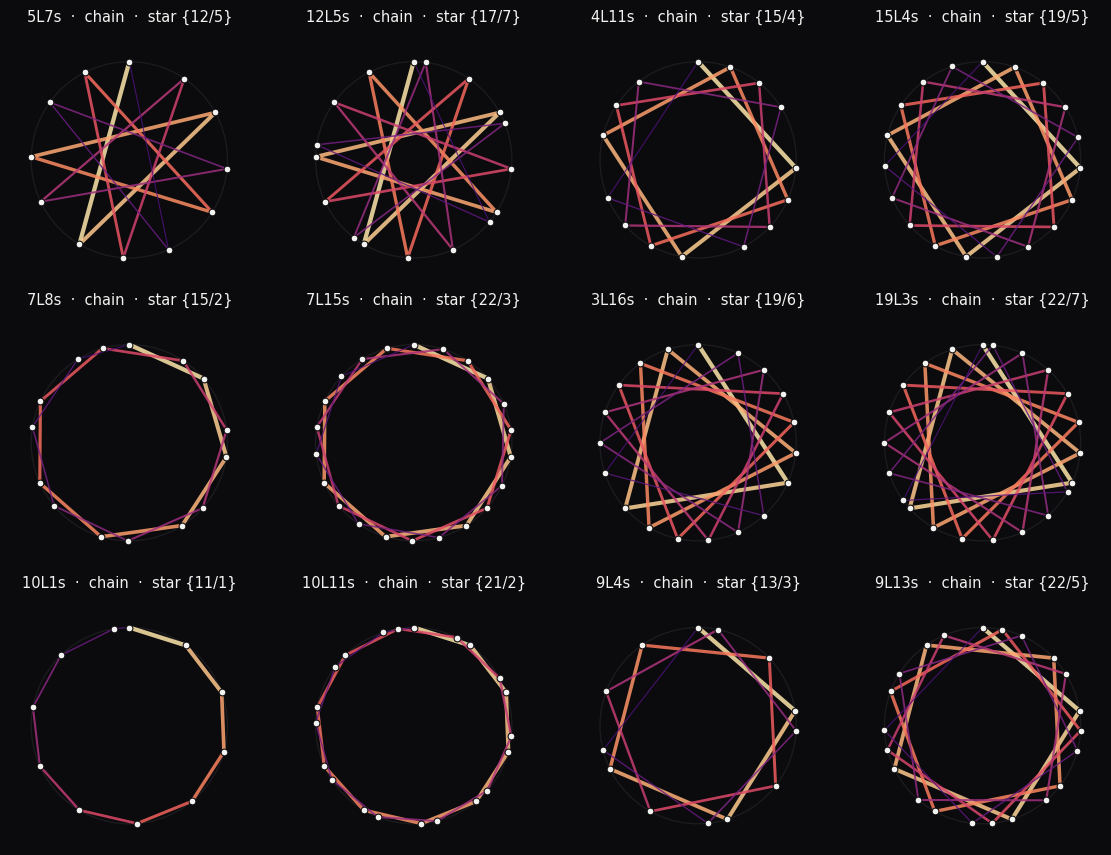

In [18]:
# A design sheet: two scales from each of several generators.
scales = []
for g in [3/2, 2**(316/1200), 2**(163.9/1200), 2**(380/1200), 2**(117/1200), 2**(271/1200)]:
    scales += [s for s in M.mos_family(g, 24) if 5 <= s.cardinality <= 24][-2:]
M.plot_web_gallery(scales[:12], "chain", palette="noir", n_cols=4, panel=3.0)
plt.show()

## 8. `fit_field` — where the signal lives, everywhere at once

`fit_mos` returns a ranked shortlist, which hides how the winner sits among its
neighbours. This scores the *whole* labyrinth against the same ratios.

The finding it exists to show: a signal is usually compatible with several
**disconnected** regions, not one. `islands()` counts them, treating the generator
axis as circular because the labyrinth is.

Note the field *samples* the generator axis and does not refine, so its best cell will
not match `fit_mos` to the last cent — and it applies no parsimony penalty, so it will
usually name a larger scale. Both differences are the two functions doing their
different jobs.

In [19]:
field = M.fit_field(bt.peaks_ratios, max_cardinality=22, resolution=760)
print(f"coverage       {field.coverage:.1%} of cells hold a well-formed scale at all")
print(f"best cell      {field.best()}")
print(f"islands @3 c   {field.islands(3.0)}")
print(f"islands @1 c   {field.islands(1.0)}")
print(f"chance @12     {field.chance_error(12):.2f} c")

coverage       36.5% of cells hold a well-formed scale at all
best cell      {'cardinality': 12, 'generator': 0.4144736842105263, 'generator_cents': 497.3684210526316, 'error_cents': 0.8153531518111823}
islands @3 c   68
islands @1 c   18
chance @12     25.00 c


marking 2L3s at 0.58 c


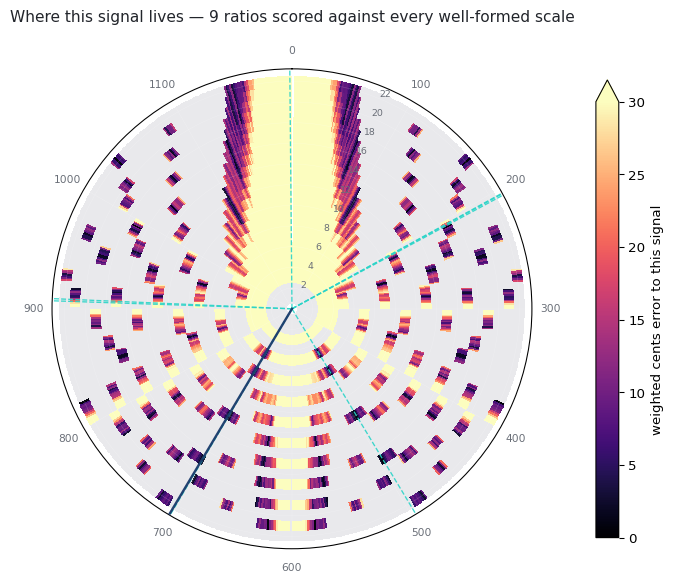

In [20]:
# The shortlist's winner, to mark on the field.
fit = M.fit_mos(bt.peaks_ratios, max_cardinality=22)[0]
print("marking", fit.signature, f"at {fit.error_cents:.2f} c")

M.plot_fit_field(field, mark=fit.scale)
plt.show()


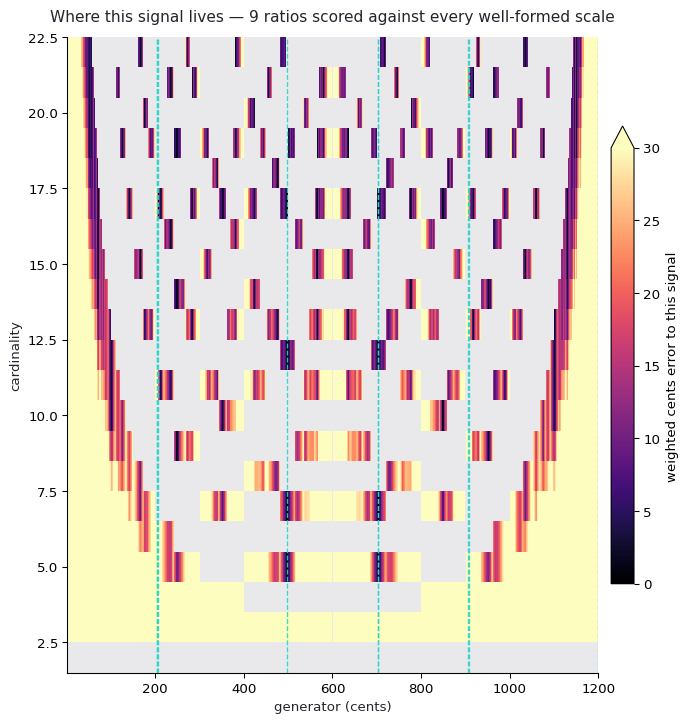

In [21]:
# Cartesian is easier to read values off.
M.plot_fit_field(field, polar=False)
plt.show()

The same idea works on the ternary simplex without any new code: the just-intonation
field already takes a target set, so passing your own ratios turns it into a fit field
over a three-step-size scale's tuning space.

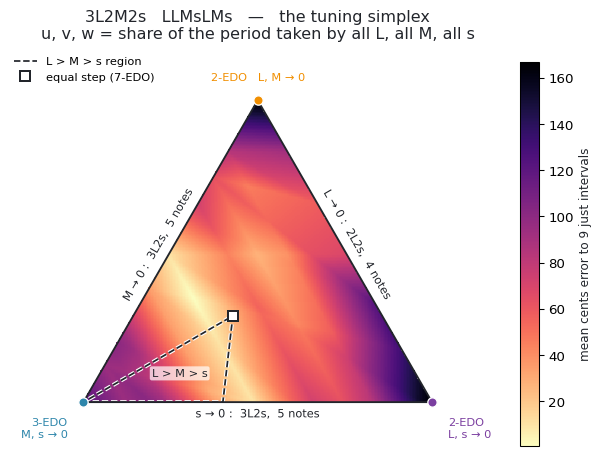

In [22]:
M.plot_ternary_simplex("LLMsLMs", field="ji_error", targets=bt.peaks_ratios)
plt.show()

## 9. The last four explorers

### `simplex_explorer` — the ternary tuning space

A three-step-size scale's tuning space is a triangle, so this is `mos_explorer`'s
counterpart for it. Two sliders place `u` and `v`; `w = 1 - u - v` follows, clamped so
the point never leaves the open simplex (a zero step is not a ternary scale).

In [23]:
M.simplex_explorer("LLMsLMs")

### `trajectory_explorer` — scrub a recording

Step through the windows of a `mos_trajectory`, watching the fit move around the
labyrinth with the path so far drawn behind it. Windows where nothing could be fitted
are shown as such rather than skipped.

In [24]:
# A recording that changes its mind half way through: fifteen seconds built on a
# chain of fifths, then fifteen on a chain of major thirds. A single fit over the
# whole thing would average the two into a scale that is in neither half.
def _chain(ratio, n=5):
    return [base * ratio ** k for k in range(n)]

half = t.size // 2
switching = np.concatenate([
    sum(a * np.sin(2 * np.pi * f * t[:half]) for a, f in zip(amps, _chain(1.5))),
    sum(a * np.sin(2 * np.pi * f * t[half:]) for a, f in zip(amps, _chain(1.25))),
])
switching = switching + 0.25 * rng.standard_normal(switching.size)

traj = M.mos_trajectory(switching, sf, window_sec=6.0, step_sec=3.0,
                        peaks_function="FOOOF", precision=0.1, n_peaks=5,
                        max_cardinality=16)
M.trajectory_explorer(traj)


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


### `dissonance_explorer` — where Dynamic Tonality earns its keep

Top: sensory roughness against interval width, harmonic timbre versus matched, with the
scale's own degrees marked. Watch the matched curve's minima pull onto the degrees.

Bottom: total scale dissonance as the generator sweeps its whole valid range, with the
coherent band shaded. This is the panel that shows where matching wins and where it
does not.

In [25]:
M.dissonance_explorer(5, 2, n_partials=8)

Two things worth knowing before you read the numbers.

**At the partials slider's floor the two timbres are identical.** A matched spectrum
cannot move partial 1, and with an octave period it cannot move partial 2 either, so at
`n_partials=2` the matched ratios are exactly `[1.0, 2.0]` and neither timbre is
smoother. The explorer says so rather than reporting a phantom result.

**Matching helps more *inside* the coherent range, not outside.** Measured over
241 generators at 8 partials:

| scale | inside coherent | outside |
|---|---|---|
| 5L2s | wins 88.0 %, median +3.39 % | wins 75.9 %, median +2.64 % |
| 4L3s | wins 84.1 %, median +2.09 % | wins 83.0 %, median +1.81 % |
| 7L5s | wins 95.5 %, median +2.10 % | wins 91.5 %, median +1.98 % |
| 2L5s | wins 75.9 %, median +1.53 % | wins 69.5 %, median +0.45 % |

The exact win fractions shift a little with the sampling grid; the direction does not.

### `matrix_explorer` — watch propriety break

Left: the interval matrix, rows = starting degree, columns = generic class. Right: the
specific sizes each generic class takes. When two adjacent classes' bands overlap, some
third is wider than some fourth — that overlap *is* impropriety, and it appears exactly
as Blackwood's R crosses 2.

In [26]:
M.matrix_explorer(5, 2)

## 10. Morphing — the labyrinth as a map you travel

Everything above reads the labyrinth as a *place*: rings, arcs, landmarks, a point where
your signal sits. `mos.morph` reads it as a map and asks the next question — how do you
get from **this** scale to **that** one?

There are three honest answers and they disagree.

| strategy | what is held | what moves | stays well-formed? |
|---|---|---|---|
| `tuning` | the structure `nL`, `ns` | the generator, continuously | yes — it slides along one arc |
| `tree` | nothing but well-formedness | the signature, one legal hop at a time | yes — it jumps between rings |
| `voice` | the note count | every tone, straight to its partner | no — almost every frame is off the map |

They are different journeys between the same two places, not three spellings of one, and
the arithmetic says so: between one pair of scales below their totals differ by a factor
of nineteen.

### `tuning_morph` — hold the structure, slide the generator

This is the Dynamic Tonality knob. Seven notes stay seven notes and the two step sizes
co-vary; nothing about the scale's identity changes except its tuning. Except once. Where
the generator passes an equalized landmark the large step and the small step trade places,
and the scale meets its own inverse coming the other way.

Meantone to anti-meantone is that trip. 5L2s at 31-EDO has a 696.8 ¢ fifth, its inverse
2L5s a 674.7 ¢ one, and 7-EDO's 685.7 ¢ sits between them. In the summary the crossing at
`t≈0.49` and the flip at `t≈0.51` are one event reported twice — from outside as a tuning
the scale passes through, from inside as a change of signature. In the trajectory it is
the instant the seven lines are evenly spaced: before it the whole tones are the wide
steps, after it they are the narrow ones, and at the crossing there is no difference left
to have.

tuning morph:  5L2s (696.8 c) -> 2L5s (674.7 c)
  frames         64
  route          5L2s -> 2L5s
  voice motion   464.5 c total
  every frame is a well-formed scale
    t=0.095  passes 19-EDO (11/19)
    t=0.492  passes 7-EDO (4/7)
    t=0.508  5L2s becomes 2L5s: the large and small steps trade places
    t=0.984  passes 16-EDO (9/16)


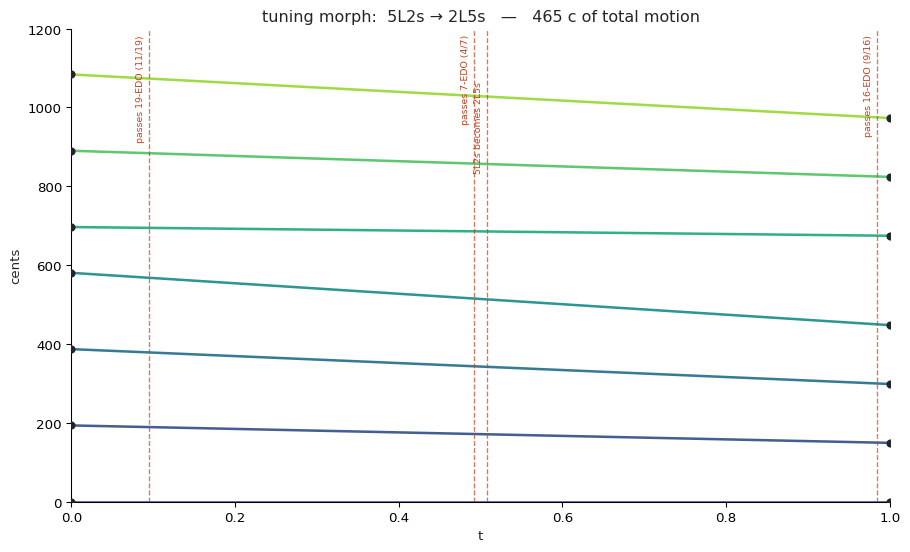

In [27]:
d31 = M.MOSScale.from_signature(5, 2, tuning=31)
slide = M.tuning_morph(d31, d31.inverse, steps=64)
print(slide.summary())

M.plot_morph_trajectory(slide)
plt.show()

### `tree_morph` — change the structure, one legal move at a time

A tuning morph cannot add a note: holding the structure fixed is precisely refusing to.
Changing the note count means hopping rings, and the labyrinth has its own connectivity
for that. A signature's two children are the Stern–Brocot mediants `(nL, nL+ns)` and
`(nL+ns, ns)` — which is why 5L2s's child 5L7s has exactly the twelve notes `embedding`
predicts — its parent is the subtractive Euclidean step back up, and one further move
swaps `(nL, ns)` for `(ns, nL)` across the landmark they share.

Pentatonic to chromatic is a walk up this tree. Shortest routes are rarely unique, so the
tie-break carries the musical judgement: among equally short routes, take the one that
stays small longest and adds notes only when it must. Both routes printed below are three
hops and every hop in both is legal; the taken one reaches twelve notes at the end, the
rejected one reaches twelve a step early and then sits there.

children of 5L2s  [(5, 7), (7, 2)]
parent of 5L2s    (3, 2)

taken    2L3s -> 3L2s -> 5L2s -> 5L7s   notes: [5, 5, 7, 12]
rejected 2L3s -> 2L5s -> 7L5s -> 5L7s   notes: [5, 7, 12, 12]

tree morph:  2L3s (700.0 c) -> 5L7s (700.0 c)
  frames         4
  route          2L3s -> 3L2s -> 5L2s -> 5L7s
  voice motion   2500.0 c total
  every frame is a well-formed scale
    t=0.000  start at 2L3s
    t=0.667  5 notes -> 7: 5L2s
    t=1.000  7 notes -> 12: 5L7s


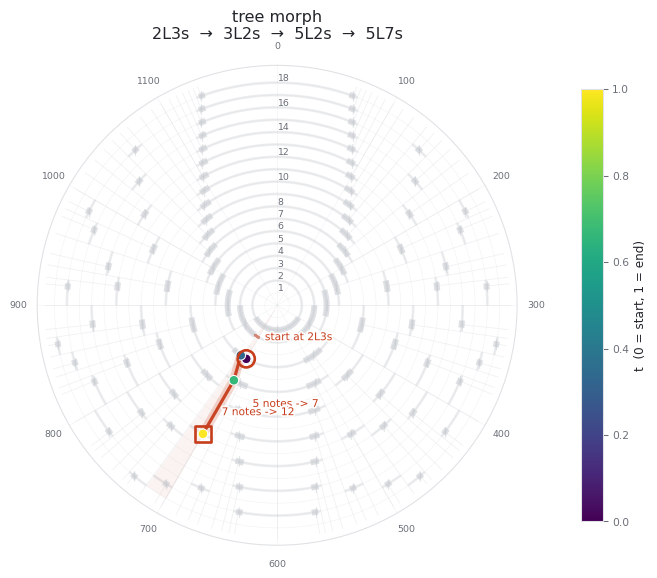

In [28]:
from biotuner.mos.morph import signature_children, signature_parent, signature_route

print("children of 5L2s ", signature_children(5, 2))
print("parent of 5L2s   ", signature_parent(5, 2))
print()

taken = signature_route((2, 3), (5, 7))
detour = [(2, 3), (2, 5), (7, 5), (5, 7)]
for name, r in (("taken   ", taken), ("rejected", detour)):
    print(name, " -> ".join(f"{a}L{b}s" for a, b in r),
          "  notes:", [a + b for a, b in r])
print()

penta = M.MOSScale.from_signature(2, 3, tuning=12)
chroma = M.MOSScale.from_signature(5, 7, tuning=12)
climb = M.tree_morph(penta, chroma)
print(climb.summary())

M.plot_morph_path(climb)
plt.show()

### `voice_morph` — move the notes and let the structure go

The third strategy asks what you would actually *hear*. Each tone glides the shorter way
round the circle to its counterpart, and where the two scales have different note counts
tones split or merge — the same thing that happens at a landmark when a step size shrinks
to nothing. Nothing holds the frames in between to being scales, and generally they are
not: `MorphStep.wellformedness` is the number of cents each frame misses being one by, and
the lower panel of the trajectory plot tracks it.

Here is the trade, priced. 5L2s and 4L3s in 19-EDO share three of their seven tones, so
the voices barely have to move. The tuning morph between the same two scales is legal in
every single frame and pays for it: to keep the structure intact it drags all seven tones
through 3-EDO at `t≈0.56`, where they collapse onto three pitches, and back out. Nineteen
times the motion, for the privilege of never leaving the map.

shared tones: 0.0 c, 568.4 c, 884.2 c



voice morph:  5L2s (694.7 c) -> 4L3s (884.2 c)
  frames         64
  route          5L2s -> (off-scale) -> 4L3s
  voice motion   378.9 c total
  leaves the labyrinth for 62 of 64 frames, by up to 10.2 c

tuning morph:  5L2s (694.7 c) -> 4L3s (884.2 c)
  frames         64
  route          5L2s -> 3L4s -> 4L3s
  voice motion   7332.3 c total
  every frame is a well-formed scale
    t=0.032  passes 12-EDO (7/12)
    t=0.127  passes 5-EDO (3/5)
    t=0.238  passes 13-EDO (8/13)
    t=0.286  passes 8-EDO (5/8)
    t=0.556  passes 3-EDO (2/3)
    t=0.571  5L2s becomes 3L4s: the large and small steps trade places
    t=0.857  passes 7-EDO (5/7)
    t=0.873  3L4s becomes 4L3s: the large and small steps trade places

voice 379 c  vs  tuning 7332 c  (19x)


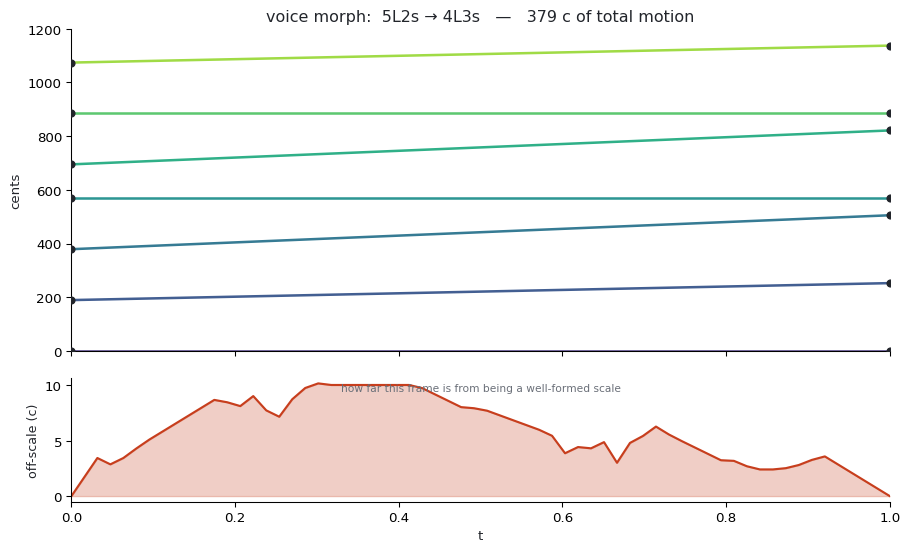

In [29]:
a19 = M.MOSScale.from_signature(5, 2, tuning=19)
b19 = M.MOSScale.from_signature(4, 3, tuning=19)
shared = sorted(set(np.round(a19.cents, 1)) & set(np.round(b19.cents, 1)))
print("shared tones:", ", ".join(f"{c:.1f} c" for c in shared))
print()

glide = M.voice_morph(a19, b19, steps=64)
slide2 = M.tuning_morph(a19, b19, steps=64)
print(glide.summary())
print()
print(slide2.summary())
print()
print(f"voice {glide.voice_leading_distance():.0f} c  vs  "
      f"tuning {slide2.voice_leading_distance():.0f} c  "
      f"({slide2.voice_leading_distance() / glide.voice_leading_distance():.0f}x)")

M.plot_morph_trajectory(glide)
plt.show()

### All three at once

Read down a column for one journey, across a row to compare them. Top: the path on the
labyrinth, where the shape alone says which strategy it was — a slide along one arc, a
climb between rings, and one that is mostly *absent*, its two banks joined by a dotted
line across the frames it spends off the map. Bottom: the same three journeys as voice
leading, with their totals.

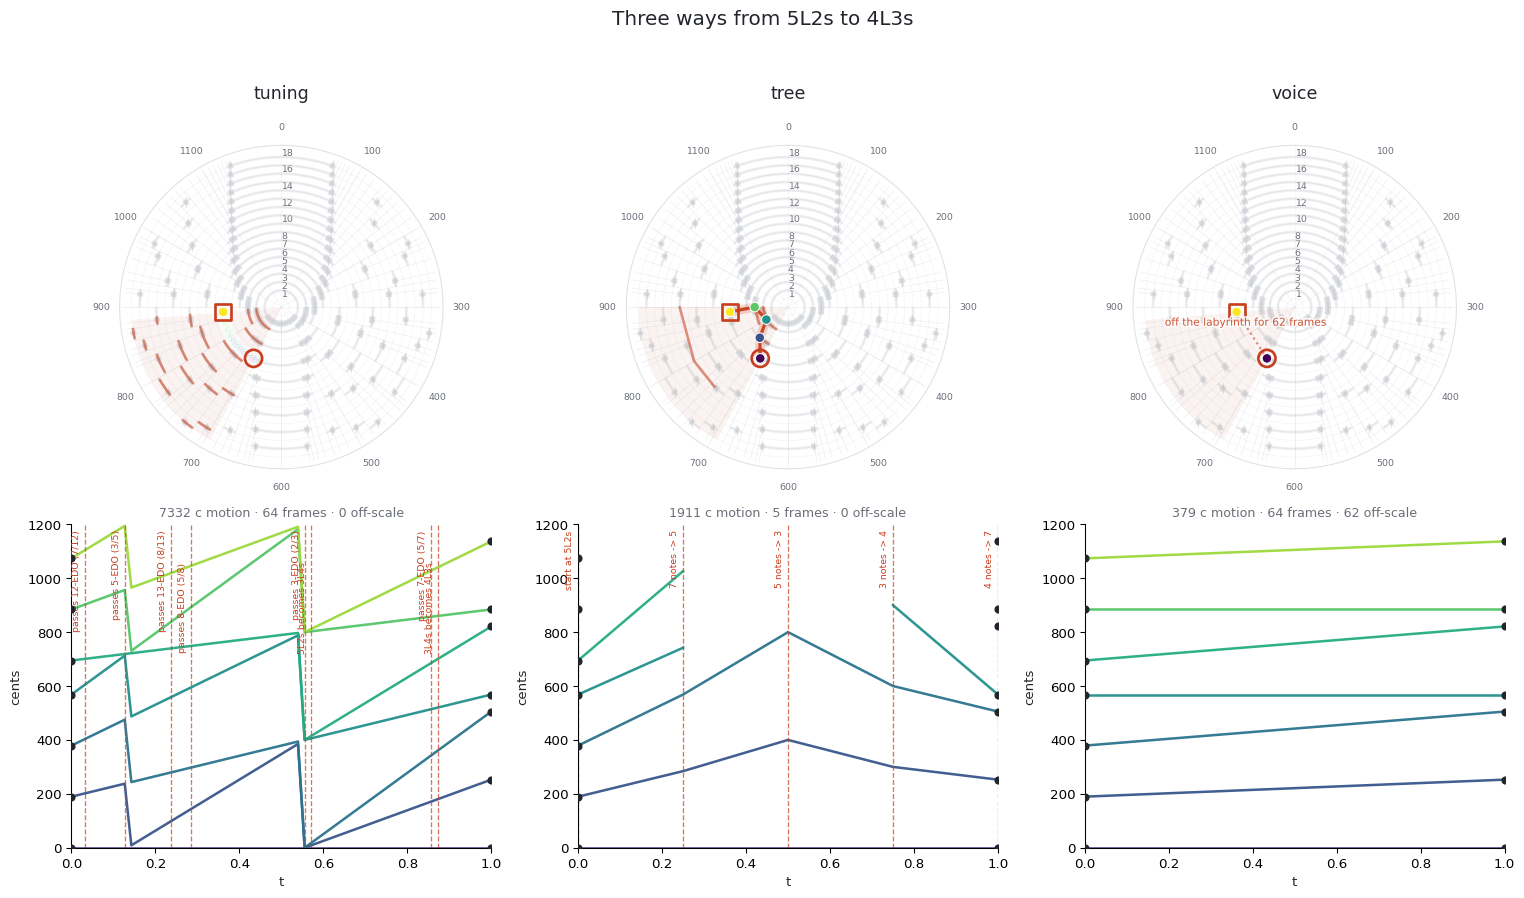

tuning   64 frames     7332 c    0 off-scale   5L2s -> 3L4s -> 4L3s
tree      5 frames     1911 c    0 off-scale   5L2s -> 3L2s -> 1L2s -> 1L3s -> 4L3s
voice    64 frames      379 c   62 off-scale   5L2s -> (off-scale) -> 4L3s


In [30]:
fig, morphs = M.plot_morph_comparison(a19, b19, steps=64)
plt.show()

for name, mm in morphs.items():
    off = sum(1 for s in mm if not s.is_well_formed)
    print(f"{name:7s} {len(mm):3d} frames  {mm.voice_leading_distance():7.0f} c  "
          f"{off:3d} off-scale   {' -> '.join(mm.signatures())}")

### `morph_explorer` — drive it yourself

`from L`/`from s` and `to L`/`to s` set the two signatures, `EDO` tunes both endpoints,
and `strategy` switches the journey with the pair held fixed — which is how you see *why*
the three disagree rather than merely that they do. Move `to s` from 3 to 7 and the tree
route lengthens from four hops to five while the voice morph is unchanged in shape, still
start, off the map, end.

The same move takes `tuning` away entirely, and the widget lets you find that out by
pressing the button rather than by hiding it: it prints that you cannot slide a seven-note
scale into an eleven-note one. That is the lesson, not an error. (Two signatures with a
common factor, and signatures the chosen `EDO` cannot spell — 5L7s has no 19-EDO
generator — have no endpoint to build from at all; change `EDO` first.)

`listen` renders the current morph with `morph_audio` — every tone of the scale as one
continuous glide, so what you hear is the movement rather than a sequence of chords — and
drops an audio player below the plot; `seconds` sets its length. The nineteen-fold
difference above is far more obvious in the ear than in the figure: one morph wanders
through three equal divisions on its way, the other barely moves.

In [31]:
M.morph_explorer((5, 2), (4, 3), tuning=19)